# Task A â€” Exploratory Data Analysis: SMAP Telemetry
> **BAFAD Accelerated Research Track Â· Fall 2026**

In this notebook you will explore a sample of telemetry data drawn from NASA's Soil Moisture Active Passive (SMAP) satellite â€” the same dataset used in the BAFAD anomaly-detection research project.

**Your job:** Complete every cell marked `# YOUR CODE HERE`. Read the instructions carefully; output cells show what a correct result looks like.

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## 1 Â· Setup and Data Loading

Run this cell as-is â€” it loads all required libraries and reads the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Fixed style matching STAT 270 colour scheme
NAVY  = '#021B3A'
BLUE  = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

# Load the sample dataset
df = pd.read_csv('../data/smap_sample.csv')
print(f'Loaded: {df.shape[0]} rows Ã— {df.shape[1]} columns')

Loaded: 500 rows Ã— 27 columns


## 2 Â· First Look at the Data

**A. (2 pts)** Use `.info()` and `.describe()` to inspect the dataset. In the markdown cell below, answer:
- How many telemetry channels are there?
- What does the `anomaly` column represent?
- Are there any missing values?

In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  500 non-null    int64  
 1   chan_00    500 non-null    float64
 2   chan_01    500 non-null    float64
 3   chan_02    500 non-null    float64
 4   chan_03    500 non-null    float64
 5   chan_04    500 non-null    float64
 6   chan_05    500 non-null    float64
 7   chan_06    500 non-null    float64
 8   chan_07    500 non-null    float64
 9   chan_08    500 non-null    float64
 10  chan_09    500 non-null    float64
 11  chan_10    500 non-null    float64
 12  chan_11    500 non-null    float64
 13  chan_12    500 non-null    float64
 14  chan_13    500 non-null    float64
 15  chan_14    500 non-null    float64
 16  chan_15    500 non-null    float64
 17  chan_16    500 non-null    float64
 18  chan_17    500 non-null    float64
 19  chan_18    500 non-null    float64
 20  chan_19    500 non-nu

,timestamp,chan_00,chan_01,chan_02,chan_03,chan_04,chan_05,chan_06,chan_07,chan_08,chan_09,chan_10,chan_11,chan_12,chan_13,chan_14,chan_15,chan_16,chan_17,chan_18,chan_19,chan_20,chan_21,chan_22,chan_23,chan_24,anomaly
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,15030.000000,0.014707,0.012190,0.028274,0.019272,0.007134,-0.001609,-0.008584,-0.008491,-0.021960,-0.021879,-0.016384,-0.013107,-0.016112,0.008098,0.002462,0.029709,0.039780,0.022125,0.033303,0.023156,0.019360,-0.002823,-0.014540,-0.044000,-0.039156,0.04800
std,8668.909966,0.356819,0.419378,0.437221,0.429701,0.481541,0.463448,0.479479,0.515423,0.533819,0.564569,0.587058,0.604458,0.637061,0.670690,0.660033,0.686901,0.709725,0.732462,0.740952,0.760108,0.792660,0.846386,0.822671,0.865636,0.871447,0.21398
min,60.000000,-0.588100,-3.564040,-0.654510,-0.714480,-3.257240,-0.757030,-0.854760,-0.855550,-0.837470,-0.869260,-0.898410,-0.925940,-4.492030,-3.865840,-2.863230,-1.108100,-1.113290,-3.030020,-1.119810,-1.173830,-1.148730,-5.019940,-1.295860,-3.643910,-1.314230,0.00000
25%,7545.000000,-0.328545,-0.368602,-0.365287,-0.394363,-0.426525,-0.455228,-0.478065,-0.508625,-0.559280,-0.589692,-0.582575,-0.603280,-0.602375,-0.613920,-0.631305,-0.644635,-0.676052,-0.690743,-0.710070,-0.722268,-0.750848,-0.757110,-0.814723,-0.860980,-0.913103,0.00000
50%,15030.000000,0.037820,0.042780,0.032710,0.038110,0.051000,0.009465,-0.019030,-0.004145,-0.059320,-0.050915,-0.050925,-0.053205,-0.002570,0.008510,0.006980,0.038925,0.050270,0.058320,0.082505,0.037025,0.048545,-0.000495,-0.036935,-0.080565,-0.085385,0.00000
75%,22515.000000,0.365538,0.387972,0.418593,0.420992,0.443580,0.458758,0.456877,0.475345,0.516820,0.526960,0.547230,0.573813,0.596963,0.619107,0.645150,0.695758,0.723555,0.732325,0.766210,0.780995,0.756782,0.783923,0.800028,0.833910,0.816553,0.00000
max,30000.000000,0.616390,0.619560,3.338690,2.139420,3.036740,0.764780,0.771170,2.468480,0.827830,2.451580,2.571810,2.907830,0.968850,3.374750,1.005480,3.099330,3.524870,1.118980,1.125470,1.184130,4.287770,3.879340,1.252730,1.264990,1.323300,1.00000


**Your answer (2–4 sentences):**

There are 25 telemetry channels, named `chan_00` through `chan_24`, plus timestamp and anomaly columns. The `anomaly` column is a binary label: 1 marks an anomalous timestep and 0 marks a normal timestep. All 500 rows have values in all 27 columns, so there are no missing values.

## 3 Â· Anomaly Prevalence

**B. (3 pts)** Compute the number and percentage of timesteps labelled as anomalies (`anomaly == 1`).
Print a sentence like: *'X of 500 timesteps are anomalies (Y.Y%).'*

In [3]:
n_anomaly = int(df['anomaly'].eq(1).sum())
pct = 100 * n_anomaly / len(df)
print(f'{n_anomaly} of {len(df)} timesteps are anomalies ({pct:.1f}%).')

24 of 500 timesteps are anomalies (4.8%).


## 4 Â· Time-Series Visualisation

**C. (5 pts)** Plot `chan_00` (y-axis) against `timestamp` (x-axis) as a line chart.
- Use `NAVY` for normal timesteps and mark anomalies as red scatter points (`'r.'`, size 8).
- Label axes and add a title: *'SMAP Channel 00 â€” Telemetry with Anomalies Highlighted'*.
- Apply `plt.tight_layout()`.

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['timestamp'], df['chan_00'], color=NAVY, label='Telemetry')
flagged = df['anomaly'].eq(1)
ax.plot(df.loc[flagged, 'timestamp'], df.loc[flagged, 'chan_00'], 'r.', markersize=8, label='Anomaly')
ax.set_xlabel('Timestamp (seconds)')
ax.set_ylabel('Channel 00 Value')
ax.set_title('SMAP Channel 00 — Telemetry with Anomalies Highlighted')
ax.legend()
plt.tight_layout()
plt.show()

## 6 Â· Distribution of Channel Values

**E. (5 pts)** For `chan_00`, plot a histogram of values for **normal** timesteps vs **anomaly** timesteps side-by-side (use `alpha=0.6`).
- Use `NAVY` for normal, `BLUE` for anomaly.
- Add a legend and axis labels.

What do you notice about the two distributions?

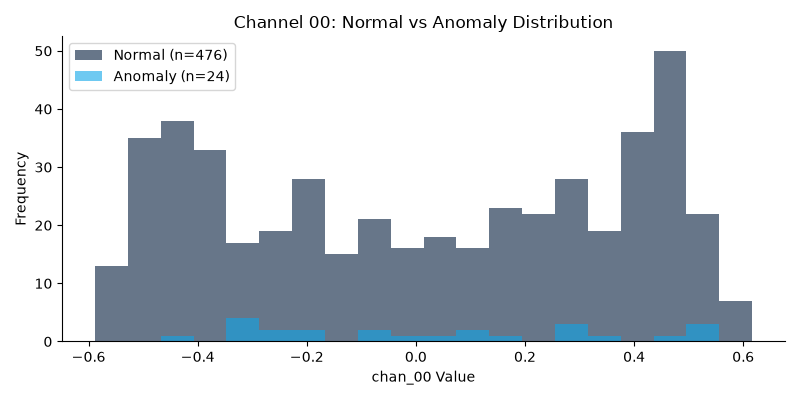

In [6]:
normal = df.loc[df['anomaly'].eq(0), 'chan_00']
anomaly = df.loc[df['anomaly'].eq(1), 'chan_00']
fig, ax = plt.subplots(figsize=(8, 4))
# Common bins allow direct comparison, following the starter's overlapping-histogram instruction.
bins = np.histogram_bin_edges(df['chan_00'], bins=20)
ax.hist(normal, bins=bins, color=NAVY, alpha=0.6, label='Normal (n=476)')
ax.hist(anomaly, bins=bins, color=BLUE, alpha=0.6, label='Anomaly (n=24)')
ax.set_xlabel('chan_00 Value')
ax.set_ylabel('Frequency')
ax.set_title('Channel 00: Normal vs Anomaly Distribution')
ax.legend()
plt.tight_layout()
plt.show()

**Your observation:**

The anomalous values (about −0.43 to 0.54) lie inside the normal range (about −0.59 to 0.62), so the two distributions overlap strongly. The normal histogram has much higher counts partly because it contains 476 observations versus only 24 anomalies. A single extreme-value cutoff on channel 00 would therefore miss labelled anomalies.

## 7 Â· Reflection (2 pts)

Answer in the cell below (3â€“5 sentences total):

1. What surprised you most about the SMAP telemetry data?
2. How might the EDA patterns you observed here guide the design of an anomaly-detection model?

**Your reflection:**

A striking result is that labelled anomalies do not necessarily appear as extreme values in channel 00. Only 24 of 500 timesteps (4.8%) are labelled anomalous, and their channel 00 values overlap the normal range. This suggests examining relationships across channels and temporal windows rather than relying on one-channel thresholds. An autoencoder could learn normal multichannel patterns, but its reconstruction-error threshold would need validation against the labels; the class imbalance also makes accuracy alone a weak evaluation measure.